In [102]:
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [21]:
dataset_path = Path(r"C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\data\raw\VGGFace2 (recognition_dataset)")
train_path = dataset_path/"train"

print(dataset_path.exists())
print(train_path.exists())
print(val_path.exists())

True
True
True


In [26]:
train_folders = list(train_path.iterdir())

print(f"Total items: {len(train_folders)}")
print()

for item in train_folder[:10]:
    print(item)
print()

for folder in train_folders:
    print(folder.name, "| Is folder:", folder.is_dir())

Total items: 480

C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000002
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000003
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000004
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000005
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000006
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000007
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000008
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000010
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000011
C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 

In [46]:
image_counts = {}

for folder in train_folders:
    images = list(folder.iterdir())
    image_counts[folder.name] = len(images)

print("Total identities:", len(image_counts))
print("Total images:", sum(image_counts.values()))

Total identities: 480
Total images: 176398


In [57]:
df_counts = pd.DataFrame(
    list(image_counts.items()),
    columns=["identity", "num_images"]
)

df_counts.head(30)

,identity,num_images
0,n000002,315
1,n000003,205
2,n000004,387
3,n000005,229
4,n000006,485
5,n000007,259
6,n000008,273
7,n000010,156
8,n000011,380
9,n000012,382


In [55]:
df_counts.describe()

,num_images
count,480.000000
mean,367.495833
std,103.206908
min,102.000000
25%,292.750000
50%,369.000000
75%,436.000000
max,720.000000


Text(0.5, 1.0, 'Distribution of Image per Odentity')

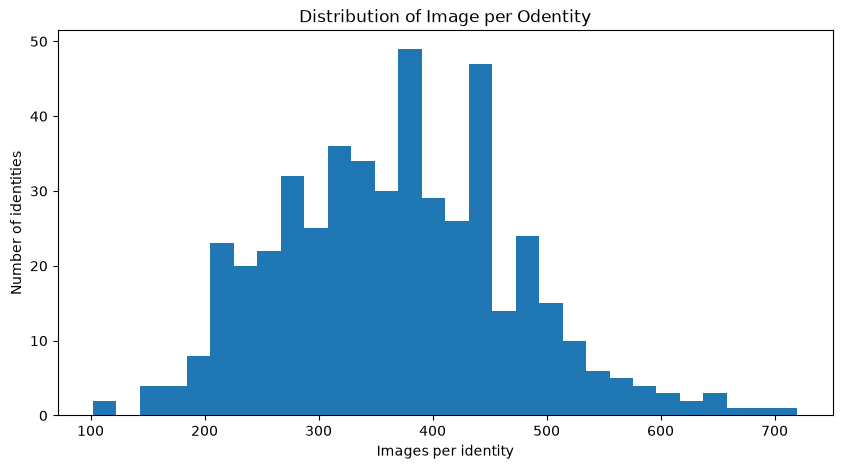

In [62]:
plt.figure(figsize=(10, 5))
plt.hist(df_counts["num_images"], bins=30)
plt.xlabel("Images per identity")
plt.ylabel("Number of identities")
plt.title("Distribution of Image per Odentity")

In [66]:
sample_identity = train_folders[0]
sample_images = list(sample_identity.iterdir())

print(sample_identity.name)
print("Number of images: ", len(sample_images))
print("First image: ", sample_images[0])

n000002
Number of images:  315
First image:  C:\Users\HP\Documents\Codes\Projects\ML\Face Recognition System\Data\Raw\VGGFace2 sub\train\n000002\0001_01.jpg


(509, 467, 3)


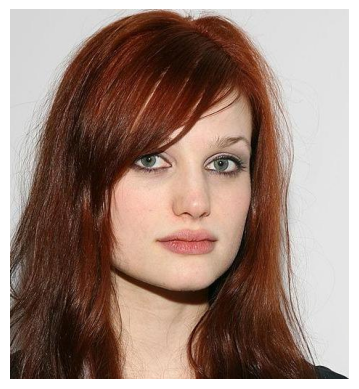

In [113]:
img = cv2.imread(str(sample_images[2]))
print(img.shape)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [118]:
sizes =[]

for folder in train_folders[:50]:
    images = list(folder.iterdir())[:50]

    for img_path in images:
        image = cv2.imread(str(img_path))
        if image is not None:
            h, w = image.shape[:2]
            sizes.append((h, w))

sizes[:20]

[(622, 544),
 (403, 393),
 (509, 467),
 (299, 290),
 (298, 260),
 (480, 497),
 (96, 89),
 (333, 338),
 (216, 189),
 (361, 316),
 (307, 231),
 (304, 266),
 (361, 316),
 (130, 122),
 (324, 279),
 (151, 133),
 (217, 190),
 (317, 277),
 (339, 288),
 (331, 290)]

In [123]:
heights = [h for h, w in sizes]
widths = [w for h, w in sizes]
ratios = [w/h for h, w in sizes]

print("Min height: ", min(heights))
print("Max height: ", max(heights))
print("Avg height: ", np.mean(heights))
print()
print("Min width: ", min(widths))
print("Max width: ", max(widths))
print("Avg width: ", np.mean(widths))
print()
print("Min ratio: ", min(ratios))
print("Max ratio: ", max(ratios))
print("Avg ratio: ", np.mean(ratios))

Min height:  61
Max height:  1168
Avg height:  288.0504

Min width:  54
Max width:  938
Avg width:  270.6976

Min ratio:  0.5826086956521739
Max ratio:  1.7081081081081082
Avg ratio:  0.9340948225903186
